In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [12]:
# Load the data
file_name = 'results_RL.csv'
data = pd.read_csv(file_name)
data.columns

Index(['Round', 'C ratio per steps', 'Rewards', 'Aggregated C ratio',
       'Number of connections', 'Pair actions'],
      dtype='object')

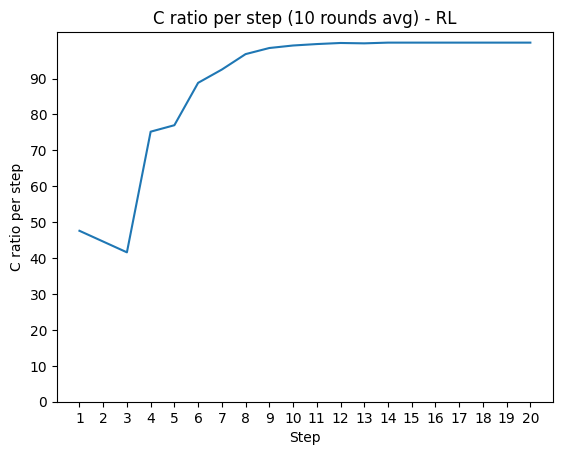

In [13]:
# now, create the above plot but average everything over the rows
# get the y-axis data from column C ratio per steps
y = data['C ratio per steps'].apply(lambda x: x.split(','))
# convert a string of a list to the list
# remove [ and ] from the string
y = y.apply(lambda x: [i.replace('[', '') for i in x])
y = y.apply(lambda x: [i.replace(']', '') for i in x])

y = y.apply(lambda x: list(map(float, x)))
# average every column in y
y = pd.DataFrame(y.tolist())
# get the standard deviation of every column
std = y.std(axis=0)
# now, get the mean of every column
y = y.mean()
y = [i*100 for i in y]

# also get the standard deviation of every column
# make the y-axis data a list

# get the x-axis data
x = range(1, len(y)+1)
# plot
plt.plot(x, y)
plt.fill_between(x, y-std, y+std, alpha=0.2)
plt.xlabel('Step')
plt.ylabel('C ratio per step')
plt.title(f'C ratio per step (10 rounds avg) - {file_name.split(".")[0].split("_")[1]}')
# make the x axis show integer only
plt.xticks(np.arange(1, len(y)+1, 1.0))
# make the y axis show 2 decimal places
plt.yticks(np.arange(0, 100, 10))
plt.show()
